# Salamander Disease Model — Design v6

## Model Structure

### Strata
- **Offspring strata:** S (susceptible), I (infected) — no movement between sites
- **Adult strata:** R_a (cleared), R_c (chronic carrier) — movement between sites in pre-season window only (custom MovementClause, pending)

### Transmission Pathways (three)
1. **S → I offspring** (fast, density-dependent) — within-pond larval epidemic driven by `beta` (temperature-scaled Gaussian peaked at 22°C). Explosive outbreak once ATV is introduced.
2. **R_a → R_c adults** (slow, persistent) — horizontal adult-to-adult transmission at rate `beta_adult` (~0.03). Adults carry ATV sublethally; this is the year-over-year reservoir mechanism. R_c should remain ~40% of total adults at steady state.
3. **R_c → S offspring** (environmental, cross-strata) — R_c adults contaminate pond water/sediment, infecting S larvae without direct contact. Governed by `beta_env` (~0.05) in `meta_edges` because it crosses strata.

### Parameter Intuitions
- `beta` (~0.12 max) >> `beta_env` (~0.001) >> `beta_adult` (~0.03)
- Larvae spread it fastest; adults spread it slowest
- Movement (pending custom MovementClause) is the key driver of between-pond spread

### Maturation fates for infected (I) offspring — three branches:
1. Disease death → DEATH: p_disease_death = 0.20
2. Chronic carrier → R_c: p_chronic = 0.50
3. Cleared → R_a: 1 - p_chronic = 0.50

### Births
- Proportional to total adult population (R_a + R_c)
- **p_vert = 0** (no evidence for vertical transmission per literature)
- All births produce S offspring
- Birth pulse: days 135–142 (start of active season)

### Deaths
- Natural mortality out of every compartment
- Higher winter mortality (1/365), lower summer (1/(365×3))
- Adult disease mortality stays low — adults are reservoirs, not casualties

### Seasonality
- Active season: May 15 (day 135) to September 15 (day 258)
- Pre-season movement window: day 105–135 (custom MovementClause, pending)
- Maturation pulse: days 257–259

### Movement
- **mm.No() used as placeholder for adults** — mm.Flat() is NOT used because it has no seasonal gating and produces unrealistic constant daily churn (confirmed by Tyler).
- Custom MovementClause subclass is the next major engineering task (see TODO cell).


In [35]:
# =====================
# Imports and SSL Setup
# =====================

import certifi
import os
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()
os.environ["SSL_CERT_FILE"] = certifi.where()

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import platformdirs
from epymorph.kit import *  # noqa
from pathlib import Path
from sympy import Max
from datetime import date
from epymorph.adrio import us_tiger, prism as prism_adrio

In [36]:
# ==========================================
# Load Temperature and Precipitation (PRISM)
# ==========================================
# Epymorph handles caching internally — data is only downloaded once.
# estimate_data() will report whether data comes from cache or a fresh download.

cache_dir = platformdirs.user_cache_dir("epymorph")

coconino_scope = CountyScope.in_counties(["04005"], year=2020)
temp_time_frame = TimeFrame.range(date(2020, 1, 1), date(2020, 12, 31))

mean_temp_adrio = prism_adrio.Temperature("Mean")
precip_adrio = prism_adrio.Precipitation()

with sim_messaging(live=False):
    temperature_data = mean_temp_adrio.with_context(
        scope=coconino_scope,
        time_frame=temp_time_frame,
        params={"centroid": us_tiger.GeometricCentroid()},
    ).evaluate()

    precip_data = precip_adrio.with_context(
        scope=coconino_scope,
        time_frame=temp_time_frame,
        params={"centroid": us_tiger.GeometricCentroid()},
    ).evaluate()

daily_temps = temperature_data[:, 0]
daily_precip = precip_data[:, 0]

print(f"Temperature — Min: {daily_temps.min():.1f}°C, Max: {daily_temps.max():.1f}°C")
print(f"Precipitation — Min: {daily_precip.min():.1f}mm, Max: {daily_precip.max():.1f}mm")

Temperature — Min: -8.6°C, Max: 24.9°C
Precipitation — Min: 0.0mm, Max: 48.3mm


In [37]:
# =====================
# Load Custom Pond Data
# =====================

try:
    current_dir = Path(__file__).resolve().parent
except NameError:
    # works in Jupyter notebooks — resolves to wherever the notebook file is
    current_dir = Path().resolve().parent

current_dir = Path().resolve().parent

test_data_path = current_dir / "data" / "basicTestData.csv"

df = pd.read_csv(test_data_path)

site_ids = df["site_id"].astype(str).tolist()
scope = CustomScope(site_ids)

total_pop = np.array(df["n_salamanders"].tolist(), dtype=int)

seed_location_index = 2
seed_size = int(df.loc[seed_location_index, "initial_infected"])

# One year timeframe
time = TimeFrame.of("2020-01-01", duration_days=365)

adult_frac = 0.40
adult_pop = np.floor(total_pop * adult_frac).astype(int)
offspring_pop = (total_pop - adult_pop).astype(int)

In [38]:
# ========================
# Compute Distance Matrix
# ========================
# TODO: implement haversine distance matrix from pond lat/lon coordinates
# Requires lat and lon columns in basicTestData.csv
# Will be used by the seasonal movement model below

In [39]:
# =========================
# Variables for Seasonality
# =========================

season_start = 135  # May 15
season_end = 258    # September 15

In [40]:
# ================================
# Offspring IPM: S, I + deaths
# ================================

class OffspringSI(CompartmentModel):
    compartments = [
        compartment("S", "susceptible offspring"),
        compartment("I", "infected offspring"),
    ]

    requirements = [
        AttributeDef("beta", type=float, shape=Shapes.TxN,
                     comment="offspring transmission rate"),
        AttributeDef("death_rate", type=float, shape=Shapes.TxN,
                     comment="offspring natural mortality rate"),
        AttributeDef("disease_death_rate", type=float, shape=Shapes.TxN,
                     comment="disease-induced death rate during season")
    ]

    def edges(self, symbols: ModelSymbols) -> list[TransitionDef]:
        S, I = symbols.all_compartments
        beta, mu, disease_death_rate = symbols.all_requirements

        N = Max(1, S + I)

        return [
            # Density-dependent transmission within offspring pool
            edge(S, I, rate=beta * S * I / N),

            # Natural deaths from each compartment
            edge(S, DEATH, rate=mu * S),
            edge(I, DEATH, rate=mu * I),
            edge(I, DEATH, rate=disease_death_rate * I)
        ]

In [41]:
# ================================================
# Adult IPM: R_a (cleared), R_c (chronic carrier)
# ================================================
# R_a → R_c: slow horizontal adult-to-adult transmission at rate beta_adult.
# Adults carry ATV sublethally (sublethal = reservoir, not casualty).
# At beta_adult = 0.03, R_c should settle near ~40% of total adults at steady state.

class AdultRaRc(CompartmentModel):
    compartments = [
        compartment("R_a", "cleared adult salamanders"),
        compartment("R_c", "chronic carrier adult salamanders"),
    ]

    requirements = [
        AttributeDef("death_rate", type=float, shape=Shapes.TxN,
                     comment="adult natural mortality rate"),
        AttributeDef("beta_adult", type=float, shape=Shapes.TxN,
                     comment="adult-to-adult horizontal transmission rate (slow, sublethal); ~0.03"),
    ]

    def edges(self, symbols: ModelSymbols) -> list[TransitionDef]:
        R_a, R_c = symbols.all_compartments
        mu, beta_adult = symbols.all_requirements

        N_adult = Max(1, R_a + R_c)

        return [
            # Horizontal adult-to-adult transmission: R_a → R_c (slow, density-dependent)
            edge(R_a, R_c, rate=beta_adult * R_a * R_c / N_adult),

            # Natural deaths from each compartment
            edge(R_a, DEATH, rate=mu * R_a),
            edge(R_c, DEATH, rate=mu * R_c),
        ]


In [42]:
# ============================
# Multi-Strata Model Builder
# ============================

class SIR_v6(MultiStrataRUMEBuilder):
    def __init__(self):
        self.strata = [
            GPM(
                name="offspring",
                ipm=OffspringSI(),
                mm=mm.No(),  # offspring cannot move between sites
                init=init.NoInfection(),
            ),
            GPM(
                name="adult",
                ipm=AdultRaRc(),
                # mm.No() used as placeholder — mm.Flat() is WRONG here because it has no
                # seasonal gating and produces constant daily churn through fall/winter.
                # Custom SeasonalAdultMovement is the correct fix.
                mm=mm.No(),
                init=init.SingleLocation(
                    initial_compartment="R_a",
                    infection_compartment="R_c",
                    location=seed_location_index,
                    seed_size=seed_size,
                ),
            ),
        ]

        self.meta_requirements = [
            AttributeDef("mature_rate", type=float, shape=Shapes.TxN,
                         comment="end of season maturation rate"),
            AttributeDef("birth_rate", type=float, shape=Shapes.TxN,
                         comment="births per adult per day"),
            AttributeDef("p_chronic", type=float, shape=Shapes.TxN,
                         comment="probability infected offspring become chronic carriers on maturation"),
            AttributeDef("p_disease_death", type=float, shape=Shapes.TxN,
                         comment="probability infected offspring die from disease on maturation"),
            AttributeDef("beta_env", type=float, shape=Shapes.TxN,
                         comment="environmental transmission: R_c adults contaminate pond, infecting S offspring (cross-strata)"),
        ]

    def meta_edges(self, symbols: MultiStrataModelSymbols) -> list[TransitionDef]:
        S, I = symbols.strata_compartments("offspring")
        R_a, R_c = symbols.strata_compartments("adult")

        mature_rate, birth_rate, p_chronic, p_disease_death, beta_env = symbols.all_meta_requirements

        N_offspring = Max(1, S + I)

        return [
            # End of season: susceptible offspring mature to cleared adults
            edge(S, R_a, rate=mature_rate * S),

            # End of season: infected offspring fork into three fates
            fork(
                edge(I, DEATH, rate=p_disease_death * mature_rate * I),
                edge(I, R_c, rate=p_chronic * mature_rate * I),
                edge(I, R_a, rate=(1 - p_chronic) * mature_rate * I),
            ),

            # Births: all adults produce susceptible offspring (p_vert = 0 per literature)
            edge(BIRTH, S, rate=birth_rate * (R_a + R_c)),

            # Environmental transmission (cross-strata): R_c adults contaminate pond water,
            # infecting S offspring. Must live in meta_edges because it crosses strata.
            edge(S, I, rate=beta_env * S * R_c / N_offspring),
        ]


In [43]:
# ================================================
# Seasonal Beta (Temperature-Driven Transmission)
# ================================================
# Beta follows a Gaussian peaked at 22°C, the optimal temperature for ATV transmission.
# Outside the active season, beta = 0.
# sigma controls how steeply beta drops away from the optimal temperature.

class SeasonalBeta(ParamFunctionTimeAndNode):
    def __init__(self, temps: np.ndarray):
        self.temps = temps

    def evaluate1(self, day: int, node_index: int) -> float:
        beta_max = 0.000187
        beta_off = 0.0

        t_mod = day % 365

        if not (season_start <= t_mod <= season_end):
            return beta_off

        temp = self.temps[t_mod]

        optimal_temp = 22.0
        sigma = 5.0

        beta_scaled = beta_max * np.exp(-((temp - optimal_temp) ** 2) / (2 * sigma ** 2))

        return beta_scaled

In [ ]:
# =================================================
# Seasonal Adult Beta (Adult-to-Adult Transmission)
# =================================================

class SeasonalAdultBeta(ParamFunctionTimeAndNode):
    def evaluate1(self, day: int, node_indec: int) -> float:
        beta_adult_max = 0.005

In [44]:
# ===============
# Seasonal Births
# ===============
# Birth pulse occurs during the first 7 days of the active season.

class SeasonalBirths(ParamFunctionTimeAndNode):
    def evaluate1(self, day: int, node_index: int) -> float:
        birth_season = 1 / 30
        birth_off = 0.0

        t_mod = day % 365

        if season_start <= t_mod <= season_start + 7:
            return birth_season
        else:
            return birth_off

In [45]:
# ===============
# Seasonal Deaths
# ===============
# Higher mortality in winter (adults only); lower mortality in summer (adults and juveniles).

class SeasonalDeaths(ParamFunctionTimeAndNode):
    def evaluate1(self, day: int, node_index: int) -> float:
        winter = 1 / 365
        summer = 1 / (365 * 3)

        t_mod = day % 365

        if t_mod >= season_end or t_mod < season_start:
            return winter
        else:
            return summer

In [46]:
# ==================
# Seasonal Migration (IN PROGRESS)
# ==================
# Custom movement model required — built-in movement models (e.g. mm.Flat) do not support
# CustomScope because they rely on geographic coordinates to compute inter-node distances.
#
# Plan:
#   - Subclass MovementClause directly
#   - Return an NxN matrix per tick describing individuals moving from node i to node j
#   - Movement is gated to a pre-season window (day 105-135)
#   - Distance decay: exponential (e^(-d/scale))
#   - Precipitation: threshold gates movement on/off, then scales proportionally
#
# Known limitation: MovementClause cannot observe current population;
# starting population is used as a proxy (reasonable if movement is small relative to N).
#
# TODO: implement SeasonalAdultMovement once distance matrix is computed

In [47]:
# ===================
# Seasonal Maturation
# ===================
# All offspring mature to adults over a 3-day window at the end of the season (day 257-259).

class SeasonalMaturation(ParamFunctionTimeAndNode):
    def evaluate1(self, day: int, node_index: int) -> float:
        move_all = 1.0
        season = 0.0

        t_mod = day % 365

        if t_mod >= season_end - 1 and t_mod <= season_end + 1:
            return move_all
        else:
            return season

In [ ]:
# ================
# Build the RUME
# ================

rume = SIR_v6().build(
    scope=scope,
    time_frame=time,
    params={
        # Offspring IPM params
        "gpm:offspring::ipm::beta": SeasonalBeta(daily_temps),
        "gpm:offspring::ipm::death_rate": SeasonalDeaths(),
        "gpm:offspring::ipm::disease_death_rate": 1 / 365,

        # Adult IPM params
        "gpm:adult::ipm::death_rate": SeasonalDeaths(),
        "gpm:adult::ipm::beta_adult": SeasonalAdultBeta(),   # slow horizontal adult-to-adult transmission

        # Meta params
        "meta::ipm::mature_rate": SeasonalMaturation(),
        "meta::ipm::birth_rate": SeasonalBirths(),
        "meta::ipm::p_chronic": 0.5,
        "meta::ipm::p_disease_death": 0.20,
        "meta::ipm::beta_env": 0.05,          # environmental: R_c adults seed larval infections

        # Populations per strata
        "gpm:offspring::init::population": 0,
        "gpm:adult::init::population": adult_pop.tolist(),
    },
)


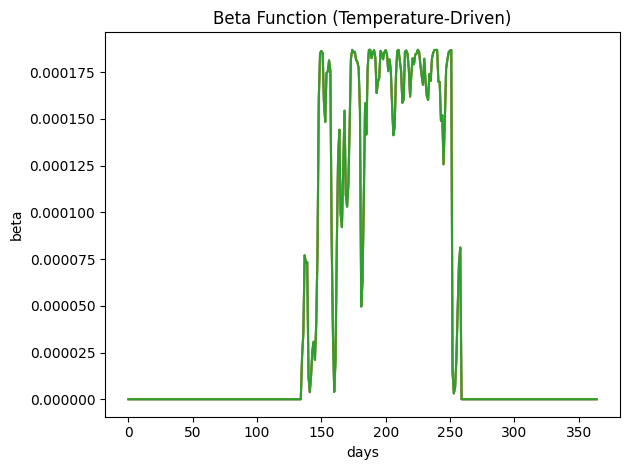

In [79]:
# ==============================
# View Beta and Model Diagram
# ==============================

beta_values = (
    SeasonalBeta(daily_temps)
    .with_context(
        scope=rume.scope,
        time_frame=rume.time_frame,
    )
    .evaluate()
)

fig, ax = plt.subplots()
ax.plot(beta_values)
ax.set(title="Beta Function (Temperature-Driven)", ylabel="beta", xlabel="days")
fig.tight_layout()
plt.show()

# build model figure (uncomment to view, takes ~15 seconds to render)
#fig = rume.ipm.diagram()

In [80]:
# ==================
# Run the Simulation
# ==================

sim = BasicSimulator(rume)
with sim_messaging(live=False):
    out = sim.run(rng_factory=default_rng(5))

df_out = out.dataframe
ponds = out.rume.scope.node_ids

Running simulation (BasicSimulator):
• 2020-01-01 to 2020-12-30 (365 days)
• 3 geo nodes
  |####################| 100% 
Runtime: 0.382s


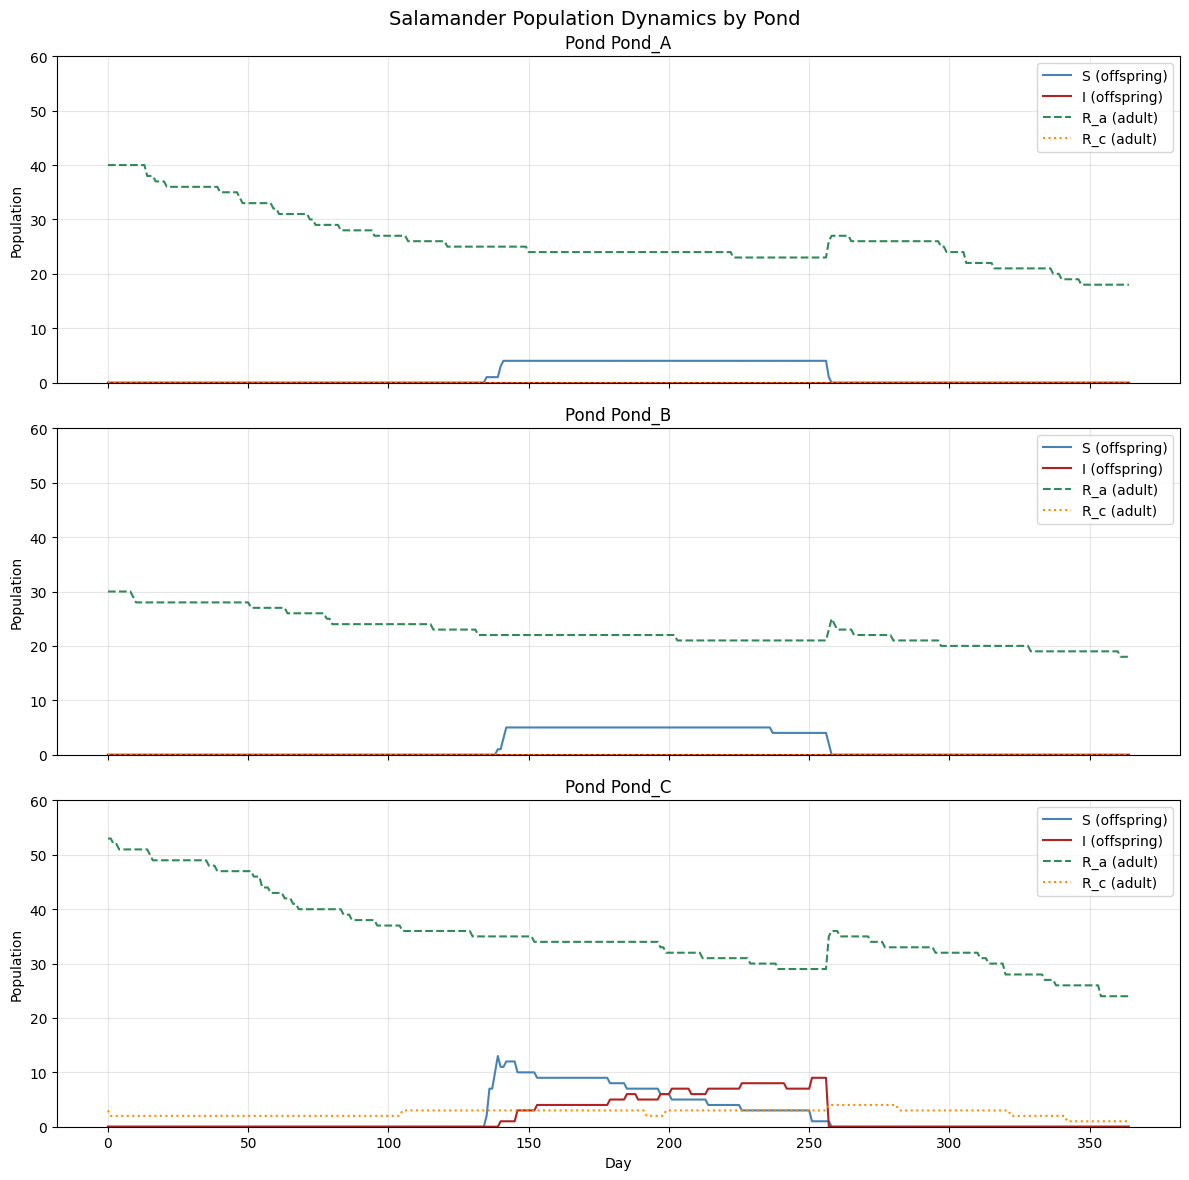

In [81]:
# ========================
# Plot Simulation Results
# ========================

fig, axes = plt.subplots(len(ponds), 1, figsize=(12, 4 * len(ponds)), sharex=True)

for ax, pond in zip(axes, ponds):
    pond_df = df_out[df_out["node"] == pond]
    ticks = pond_df["tick"].to_numpy()

    ax.plot(ticks, pond_df["S_offspring"].to_numpy(), label="S (offspring)", color="steelblue")
    ax.plot(ticks, pond_df["I_offspring"].to_numpy(), label="I (offspring)", color="firebrick")
    ax.plot(ticks, pond_df["R_a_adult"].to_numpy(), label="R_a (adult)", linestyle="--", color="seagreen")
    ax.plot(ticks, pond_df["R_c_adult"].to_numpy(), label="R_c (adult)", linestyle=":", color="darkorange")

    ax.set_title(f"Pond {pond}")
    ax.set_ylabel("Population")
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 60)

axes[-1].set_xlabel("Day")
plt.suptitle("Salamander Population Dynamics by Pond", fontsize=14)
plt.tight_layout()
plt.show()

In [82]:
# ===========
# Diagnostics
# ===========
# Check that maturation works correctly:
# all offspring should transition to adults around day 258.

print("--- Total offspring around maturation (days 254-258) ---")
tot_offspring = df_out.groupby("tick")[["S_offspring", "I_offspring"]].sum()
print(tot_offspring.loc[254:258])

print("\n--- Total adults around maturation (days 254-259) ---")
tot_adults = df_out.groupby("tick")[["R_a_adult", "R_c_adult"]].sum()
print(tot_adults.loc[254:259])

print("\n--- Offspring summary days 250-260 ---")
print(df_out.groupby("tick")[["S_offspring", "I_offspring"]].sum().loc[250:260])

--- Total offspring around maturation (days 254-258) ---
      S_offspring  I_offspring
tick                          
254             9            9
255             9            9
256             9            9
257             4            0
258             0            0

--- Total adults around maturation (days 254-259) ---
      R_a_adult  R_c_adult
tick                      
254          73          3
255          73          3
256          73          3
257          84          4
258          88          4
259          87          4

--- Offspring summary days 250-260 ---
      S_offspring  I_offspring
tick                          
250            11            7
251             9            9
252             9            9
253             9            9
254             9            9
255             9            9
256             9            9
257             4            0
258             0            0
259             0            0
260             0            0
